# Amazon ML Challenge: data audit and safe preprocessing

## Goal
Explore the three train and three test TSV sources and the training labels without loading the full dataset into memory. Preserve multilingual text. Produce cleaned source TSVs only when you explicitly enable the export cell.

**What this notebook measures by default:** the first `MAX_ROWS_PER_FILE` records of each file. This is a quick diagnostic, **not a random or representative sample**. Set `FULL_SCAN = True` for exact file-wide counts and a bounded reservoir sample across each entire file. The full scan reads roughly 3 GB and will take longer, but keeps memory bounded.

**Challenge rules:** Source 1 is the reference. Sources 2 and 3 contain possible matches. Train covers US and India; test also includes France. Keep country labels open-ended. Ground-truth match IDs are comma-separated *inside a tab-separated file*.

## 1. Setup

Install once if needed: `python -m pip install pandas matplotlib nbformat nbclient ipykernel`. Change `DATA_ROOT` if the project is elsewhere. All outputs in this notebook are bounded previews; source files remain untouched.

In [11]:
from pathlib import Path
from collections import Counter
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path(r"D:\Bunker\BaseCamp\AmazonML")
DATA_ROOT = PROJECT_ROOT / "student_resource" / "dataset"
FULL_SCAN = True
MAX_ROWS_PER_FILE = 25_000  # used only when FULL_SCAN is False
CHUNK_SIZE = 10_000
PREVIEW_ROWS = 8
RANDOM_SEED = 42
EXPORT_CLEAN_TSV = False  # deliberate opt-in; can write several GB
EXPORT_ROOT = PROJECT_ROOT / "preprocessed"

SOURCE_COLUMNS = ["entity_id", "business_name", "business_address", "country"]
FILES = {
    "train_source1": DATA_ROOT / "train" / "train_source1.tsv",
    "train_source2": DATA_ROOT / "train" / "train_source2.tsv",
    "train_source3": DATA_ROOT / "train" / "train_source3.tsv",
    "test_source1": DATA_ROOT / "test" / "test_source1.tsv",
    "test_source2": DATA_ROOT / "test" / "test_source2.tsv",
    "test_source3": DATA_ROOT / "test" / "test_source3.tsv",
    "train_ground_truth": DATA_ROOT / "train" / "train_ground_truth.tsv",
}
missing_files = [str(path) for path in FILES.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError("Missing TSV files:\n" + "\n".join(missing_files))
print(f"Data root: {DATA_ROOT}")
print(f"Scan mode: {'all rows' if FULL_SCAN else f'first {MAX_ROWS_PER_FILE:,} rows per file'}")

Data root: D:\Bunker\BaseCamp\AmazonML\student_resource\dataset
Scan mode: all rows


## 2. File inventory and schema

File sizes are exact filesystem metadata. Row counts below come from the scan mode chosen above.

In [12]:
inventory = []
for file_key, path in FILES.items():
    header = pd.read_csv(path, sep="\t", nrows=0, encoding="utf-8").columns.tolist()
    expected = ["source1_entity_id", "matched_entity_ids"] if file_key == "train_ground_truth" else SOURCE_COLUMNS
    if header != expected:
        raise ValueError(f"Unexpected columns in {path.name}: {header}; expected {expected}")
    inventory.append({"file": file_key, "size_MB": round(path.stat().st_size / 1_000_000, 1), "columns": ", ".join(header)})
display(pd.DataFrame(inventory))

,file,size_MB,columns
0,train_source1,210.1,"entity_id, business_name, business_address, co..."
1,train_source2,489.3,"entity_id, business_name, business_address, co..."
2,train_source3,503.7,"entity_id, business_name, business_address, co..."
3,test_source1,175.0,"entity_id, business_name, business_address, co..."
4,test_source2,509.5,"entity_id, business_name, business_address, co..."
5,test_source3,506.0,"entity_id, business_name, business_address, co..."
6,train_ground_truth,127.0,"source1_entity_id, matched_entity_ids"


## 3. Scan in chunks

Each chunk is parsed as TSV with strings, so IDs keep their exact spelling and empty fields stay empty strings. In quick mode, `nrows` stops parsing after the configured limit. In either mode, a fixed-size reservoir retains example rows from across the scanned portion of each file.

In [13]:
import random


def script_group(character):
    if not character.isalpha():
        return None
    name = unicodedata.name(character, "")
    for prefix in ("LATIN", "DEVANAGARI", "BENGALI", "ARABIC", "CYRILLIC", "GREEK", "HEBREW", "TAMIL", "TELUGU", "KANNADA", "MALAYALAM", "GUJARATI", "GURMUKHI", "THAI", "HANGUL", "HIRAGANA", "KATAKANA", "CJK"):
        if name.startswith(prefix):
            return prefix
    return "OTHER"


def text_scripts(value):
    return sorted({group for character in value if (group := script_group(character))})


def iter_chunks(path):
    return pd.read_csv(
        path, sep="\t", encoding="utf-8", dtype=str, keep_default_na=False,
        chunksize=CHUNK_SIZE, nrows=None if FULL_SCAN else MAX_ROWS_PER_FILE,
        on_bad_lines="error",
    )


def inspect_file(file_key, path):
    is_truth = file_key == "train_ground_truth"
    counters = {name: Counter() for name in ("country", "name_script", "address_script", "match_count", "match_source")}
    missing = Counter()
    examples = []
    row_count = 0
    rng = random.Random(RANDOM_SEED)
    preview_limit = 1_000
    for chunk in iter_chunks(path):
        for row in chunk.itertuples(index=False, name=None):
            row_count += 1
            record = dict(zip(chunk.columns, row))
            if is_truth:
                matched = [item.strip() for item in record["matched_entity_ids"].split(",") if item.strip()]
                counters["match_count"][len(matched)] += 1
                counters["match_source"].update(item.split("-", 1)[0] for item in matched)
            else:
                for field in SOURCE_COLUMNS:
                    if not record[field].strip():
                        missing[field] += 1
                counters["country"][record["country"].strip() or "<empty>"] += 1
                counters["name_script"].update(text_scripts(record["business_name"]) or ["NONE"])
                counters["address_script"].update(text_scripts(record["business_address"]) or ["NONE"])
            if len(examples) < preview_limit:
                examples.append(record)
            else:
                position = rng.randrange(row_count)
                if position < preview_limit:
                    examples[position] = record
    return {"rows_scanned": row_count, "missing": missing, "counters": counters, "examples": examples}


profiles = {file_key: inspect_file(file_key, path) for file_key, path in FILES.items()}
coverage = "complete" if FULL_SCAN else "early-row sample"
display(pd.DataFrame([
    {"file": key, "rows_scanned": value["rows_scanned"], "coverage": coverage}
    for key, value in profiles.items()
]))

,file,rows_scanned,coverage
0,train_source1,2206821,complete
1,train_source2,5034616,complete
2,train_source3,5285603,complete
3,test_source1,1732544,complete
4,test_source2,4887273,complete
5,test_source3,5082316,complete
6,train_ground_truth,2206821,complete


## 4. Inspect raw records

These examples show actual strings before any cleaning. They are a deterministic reservoir sample of the rows scanned. In quick mode this sample is still limited to the first `MAX_ROWS_PER_FILE` rows.

In [14]:
for file_key in ("train_source1", "train_source2", "train_source3", "test_source1"):
    print(file_key)
    display(pd.DataFrame(profiles[file_key]["examples"]).head(PREVIEW_ROWS))

train_source1


,entity_id,business_name,business_address,country
0,S1-524387183,Scholarship Sterling Fellowship LLC,"707 Washington Avenue, Moundsville, WV",US
1,S1-792733458,W F & N Consultants LLC,"5938 Suson Park Place, Unit APT J, Saint Louis...",US
2,S1-177593011,Narendra Software Private Limited,"29, Ist Floor, Lal Tanki Market Model Town, Pa...",India
3,S1-915951146,Frontier Rapid Redwood LLC,"OH, Sugarcreek, 3338 Tr 166",US
4,S1-679460850,Booth International LLC,"202 Hickory Drive, Roberts, IL",US
5,S1-451123727,Trading Brm House LLP,"Csn. F-7/1 & F-7/2/3, Midc, Shiroli, Hatkanang...",India
6,S1-978287418,Internal Medicine Physicians Inc.,"7002 Mason Road, Berlin Heights, OH",US
7,S1-582701802,"Caterina S. Bigby, D.O., PC","1022 18th Street, Chariton, IA",US


train_source2


,entity_id,business_name,business_address,country
0,S2-106599096,"LINDAHL, BARBE N., ESQ. INC","181 BALDRIDGE ROAD, LUCASVILLE, OH",US
1,S2-652393630,Twisted Bnrbtrsohp!,"192 F, LA PORTE, IN",US
2,S2-573261360,Green Energy Public Limited,"H.NO 8-57 C/O RAMESH KUMAR, BANKMANS COLONY K....",India
3,S2-11714798,"Vester, Macey And Simons LLC","143 NEW SHACKLE ISLAND RD, HENDERSONVILLE, TN",US
4,S2-815545822,PVT. RAJASTHAN LTD. TELEMATICS,"#350 2895, BAZAR SIRKIWALAN, IIIRD FLOOR, HAUZ...",India
5,S2-944043957,लक्ष्मी फर्स्ट हेल्थकेयर सॉल्यूशंस प्रा. लि.,"14, JAWAHAR NAGAR, KHANDARI, AGRA, Uttar Pradesh",India
6,S2-858255204,"MORTON, INGRAM AND MUNOZ LLC","GARDEN AVE, KLAMATH FALLS, OR",US
7,S2-249136699,ರಾಮ್ ಬಿಲ್ಡರ್ಸ್,"NO.157, BANGALORE, Karnataka",India


train_source3


,entity_id,business_name,business_address,country
0,S3-367251064,Geex Intrtss LLC,"3018 Indian Pvt Wells, Harilngen, Texas",US
1,S3-755522911,ಫಾರ್ಚೂನ್ ಗೋಲ್ಡ್ ಸಿಸ್ಟಮ್ಸ್ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್,"Udayavani Building Press Corner, Manipal, Dak....",India
2,S3-898614143,Ear Nose Throat Center LLC Center,"Velvet Ln, Kearneysville Township, West Virginia",US
3,S3-103419880,private madhu free limited,"दिल्ली, East Delhi, Hn 495 Bms Complex, Delhi",India
4,S3-299888256,Gujarat Constructions Private Ltd,"328 Sobo Center, Bopal, Ahmedabad, GJ",India
5,S3-393543257,Royal One Developers Limited Center,"Shop No 223, 2 Nd Floor, Vardhman Crown Mall S...",India
6,S3-482334646,Sunrise My Eports Hardware Pvt Ltd,"A- 412, Bangalore, KA",India
7,S3-484594267,Sun Engineering Private (Limited),"H.no 401, Delhi, New Delhi, DL",India


test_source1


,entity_id,business_name,business_address,country
0,S1-742079690,Classic Finance Pvt Ltd,"28, Harish Nagar Karelibaug, Vadodara, Gujarat",India
1,S1-81790884,Valley Fund of Village Of Ashwaubenon,"1207 Cormier Road, Village Of Ashwaubenon, WI",US
2,S1-163875819,High Technologies Private Limited,"Plot-331/1942, Aurabinda, Nagar, Chandrasekhar...",India
3,S1-338352940,Hitech Green Infrastructure Private Limited,"Thane, Flat -102, Maharashtra, Navi Mumbai, Ra...",India
4,S1-55644782,Premier Trading,"Pune, H. No. 24 To 79, T Flat No. 902/ B-7 Bhu...",India
5,S1-7339260,Marks Heights Private Limited,"Mumbai, 1 B, Mumbai City, Floor-Grd, Plot-142/...",India
6,S1-541681812,"Cristo, Hering & James Douglas","106 Kingfisher Lane, New Hartford, NY",US
7,S1-222695503,Indian Builders,"No. 54 Bull Temple Road, Bangalore, Karnataka",India


## 5. Country coverage and missing fields

France appears in test, so any later model must accept unseen country labels. Counts and percentages use the scanned rows as their denominator.

In [15]:
country_rows = []
missing_rows = []
for file_key, profile in profiles.items():
    if file_key == "train_ground_truth":
        continue
    denominator = profile["rows_scanned"]
    for country, count in profile["counters"]["country"].items():
        country_rows.append({"file": file_key, "country": country, "rows": count, "pct_scanned": round(100 * count / denominator, 2)})
    for field in SOURCE_COLUMNS:
        count = profile["missing"][field]
        missing_rows.append({"file": file_key, "field": field, "empty_rows": count, "pct_scanned": round(100 * count / denominator, 2)})
country_table = pd.DataFrame(country_rows)
missing_table = pd.DataFrame(missing_rows)
display(country_table.sort_values(["file", "rows"], ascending=[True, False]))
display(missing_table)

,file,country,rows,pct_scanned
8,test_source1,India,809986,46.75
6,test_source1,US,663106,38.27
7,test_source1,France,259452,14.98
9,test_source2,India,2312565,47.32
11,test_source2,US,1871330,38.29
10,test_source2,France,703378,14.39
12,test_source3,India,2405000,47.32
14,test_source3,US,1945701,38.28
13,test_source3,France,731615,14.40
0,train_source1,US,1323633,59.98


,file,field,empty_rows,pct_scanned
0,train_source1,entity_id,0,0.00
1,train_source1,business_name,0,0.00
2,train_source1,business_address,0,0.00
3,train_source1,country,0,0.00
4,train_source2,entity_id,0,0.00
5,train_source2,business_name,0,0.00
6,train_source2,business_address,168967,3.36
7,train_source2,country,0,0.00
8,train_source3,entity_id,0,0.00
9,train_source3,business_name,0,0.00


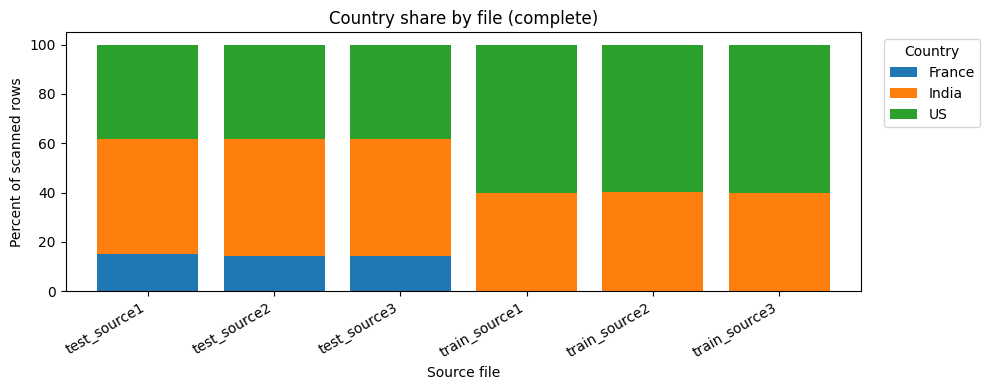

In [16]:
pivot = country_table.pivot(index="file", columns="country", values="pct_scanned").fillna(0)
ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 4), width=0.8)
ax.set(title=f"Country share by file ({coverage})", xlabel="Source file", ylabel="Percent of scanned rows")
ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6. Language script signals

This is **Unicode script detection, not language identification**. Latin can represent English, French, or transliterated Indian names. A record can contribute to more than one script count. Accents and non-Latin writing are preserved.

In [17]:
script_rows = []
for file_key, profile in profiles.items():
    if file_key == "train_ground_truth":
        continue
    for field, counter_key in (("business_name", "name_script"), ("business_address", "address_script")):
        for script, count in profile["counters"][counter_key].most_common():
            script_rows.append({"file": file_key, "field": field, "script": script, "rows_with_script": count})
script_table = pd.DataFrame(script_rows)
display(script_table.sort_values(["file", "field", "rows_with_script"], ascending=[True, True, False]).head(40))

for file_key in ("train_source2", "test_source1"):
    sample = pd.DataFrame(profiles[file_key]["examples"])
    subset = sample[sample["business_name"].map(lambda value: any(script != "LATIN" for script in text_scripts(value)))]
    print(f"{file_key}: non-Latin name examples in retained sample")
    display(subset[SOURCE_COLUMNS].head(PREVIEW_ROWS))

,file,field,script,rows_with_script
47,test_source1,business_address,LATIN,1732544
46,test_source1,business_name,LATIN,1732544
59,test_source2,business_address,LATIN,4757865
60,test_source2,business_address,DEVANAGARI,318369
61,test_source2,business_address,NONE,129408
62,test_source2,business_address,KANNADA,45006
63,test_source2,business_address,TAMIL,40621
64,test_source2,business_address,TELUGU,39624
65,test_source2,business_address,BENGALI,36832
66,test_source2,business_address,GUJARATI,36709


train_source2: non-Latin name examples in retained sample


,entity_id,business_name,business_address,country
5,S2-944043957,लक्ष्मी फर्स्ट हेल्थकेयर सॉल्यूशंस प्रा. लि.,"14, JAWAHAR NAGAR, KHANDARI, AGRA, Uttar Pradesh",India
7,S2-249136699,ರಾಮ್ ಬಿಲ್ಡರ್ಸ್,"NO.157, BANGALORE, Karnataka",India
40,S2-538690226,सेवन फाउंडेशन प्रा. लि.,"D 376, OMICRON III, BISHRAKH, null, उत्तर प्रदेश",India
43,S2-127902052,सूर्या डेवलपर्स एलएलपी,NO 13-24 WING A FLOOR NO 13 VASANT VALLEY ASTE...,India
49,S2-386213608,ನ್ಯೂ ಶಕ್ತಿ Technologies Private Limited,"BLOCK F-0751 224/Y, BENGALURU, Karnataka",India
50,S2-103297243,एसएस हॉस्पिटैलिटी प्राइवेट लिमिटेड,"6/13, KUMAR CITY SOCIETY, WADGAON SHERI, PUNE ...",India
65,S2-678000346,ग्रीन कंसल्टेंट्स प्राइवेट लिमिटेड,"UNIT NO. D/2401, B-36, EXPRESS TRADE TOWERS 2,...",India
71,S2-574804382,श्री कंस्ट्रक्शंस गारमेंट्स लिमिटेड,"UB-3-7, NEW DELHI, KASTURBA GANDHI MARG, Delhi",India


test_source1: non-Latin name examples in retained sample


,entity_id,business_name,business_address,country


## 7. Training label shape

One Source 1 record can have zero or many S2/S3 matches. These are training labels only. The test files have no labels.

,matches_per_source1,rows
6,0,123247
7,1,119157
4,2,375212
2,3,530841
1,4,484115
0,5,321957
3,6,164868
5,7,63968
8,8,18680
9,9,4205


S2/S3 matched ID occurrences: {'S2': 3693619, 'S3': 3944746}
Singleton share among scanned ground-truth rows: 5.6%


,source1_entity_id,matched_entity_ids
0,S1-946069528,"S2-935735051,S2-37993907,S2-414912781,S3-41803..."
1,S1-707465252,"S2-502637280,S2-811600410,S3-575718278,S3-9340..."
2,S1-344983729,"S2-846050547,S2-30909007,S3-164561821,S3-62531..."
3,S1-335141293,"S2-924262320,S2-858969411,S3-199518546"
4,S1-881584120,"S2-456173563,S2-20179276,S2-475798137,S3-24541..."
5,S1-837060975,"S2-728655335,S2-911715618,S2-745621199,S3-8423..."
6,S1-426450451,"S2-466770855,S3-365917808"
7,S1-490842253,"S2-907118035,S2-555844105,S2-426779814,S3-2700..."


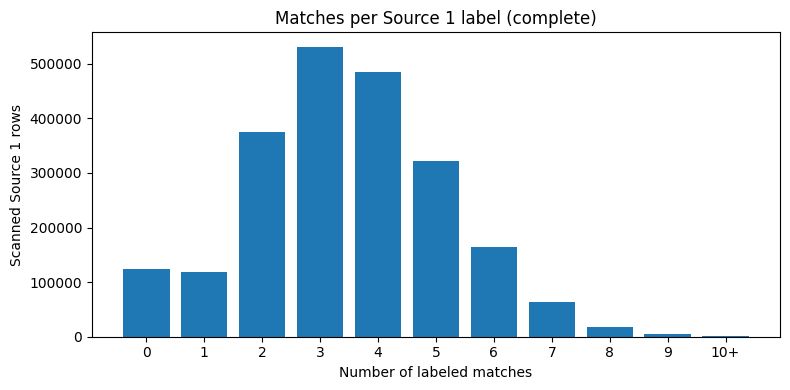

In [18]:
truth = profiles["train_ground_truth"]
truth_counts = truth["counters"]["match_count"]
display(pd.DataFrame({"matches_per_source1": list(truth_counts), "rows": list(truth_counts.values())}).sort_values("matches_per_source1").head(25))
print("S2/S3 matched ID occurrences:", dict(truth["counters"]["match_source"]))
print("Singleton share among scanned ground-truth rows:", f"{truth_counts[0] / truth['rows_scanned']:.1%}")
display(pd.DataFrame(truth["examples"]).head(PREVIEW_ROWS))

fig, ax = plt.subplots(figsize=(8, 4))
shown = {min(number, 10): 0 for number in truth_counts}
for number, count in truth_counts.items():
    shown[min(number, 10)] += count
ax.bar([str(number) if number < 10 else "10+" for number in sorted(shown)], [shown[number] for number in sorted(shown)])
ax.set(title=f"Matches per Source 1 label ({coverage})", xlabel="Number of labeled matches", ylabel="Scanned Source 1 rows")
plt.tight_layout()
plt.show()

## 8. Conservative text normalization

`NFKC` harmonizes some Unicode presentation forms; `casefold` makes casing comparable; whitespace is collapsed. This does **not** transliterate scripts, strip accents, remove punctuation, or discard legal suffixes. Keep the raw fields alongside the cleaned fields because normalization can merge distinct spellings. IDs are never normalized.

In [19]:
def normalize_text(value):
    if not value:
        return ""
    normalized = unicodedata.normalize("NFKC", value)
    return " ".join(normalized.casefold().split())


def clean_source_chunk(chunk):
    cleaned = chunk.copy()
    cleaned["business_name_clean"] = cleaned["business_name"].map(normalize_text)
    cleaned["business_address_clean"] = cleaned["business_address"].map(normalize_text)
    cleaned["country_clean"] = cleaned["country"].map(lambda value: value.strip())
    return cleaned


demo = pd.DataFrame(profiles["train_source2"]["examples"])
display(clean_source_chunk(demo)[["entity_id", "business_name", "business_name_clean", "business_address", "business_address_clean", "country_clean"]].head(PREVIEW_ROWS))
assert normalize_text("  École   राम  ") == "école राम"
assert normalize_text("ＡＢＣ  Ltd") == "abc ltd"


,entity_id,business_name,business_name_clean,business_address,business_address_clean,country_clean
0,S2-106599096,"LINDAHL, BARBE N., ESQ. INC","lindahl, barbe n., esq. inc","181 BALDRIDGE ROAD, LUCASVILLE, OH","181 baldridge road, lucasville, oh",US
1,S2-652393630,Twisted Bnrbtrsohp!,twisted bnrbtrsohp!,"192 F, LA PORTE, IN","192 f, la porte, in",US
2,S2-573261360,Green Energy Public Limited,green energy public limited,"H.NO 8-57 C/O RAMESH KUMAR, BANKMANS COLONY K....","h.no 8-57 c/o ramesh kumar, bankmans colony k....",India
3,S2-11714798,"Vester, Macey And Simons LLC","vester, macey and simons llc","143 NEW SHACKLE ISLAND RD, HENDERSONVILLE, TN","143 new shackle island rd, hendersonville, tn",US
4,S2-815545822,PVT. RAJASTHAN LTD. TELEMATICS,pvt. rajasthan ltd. telematics,"#350 2895, BAZAR SIRKIWALAN, IIIRD FLOOR, HAUZ...","#350 2895, bazar sirkiwalan, iiird floor, hauz...",India
5,S2-944043957,लक्ष्मी फर्स्ट हेल्थकेयर सॉल्यूशंस प्रा. लि.,लक्ष्मी फर्स्ट हेल्थकेयर सॉल्यूशंस प्रा. लि.,"14, JAWAHAR NAGAR, KHANDARI, AGRA, Uttar Pradesh","14, jawahar nagar, khandari, agra, uttar pradesh",India
6,S2-858255204,"MORTON, INGRAM AND MUNOZ LLC","morton, ingram and munoz llc","GARDEN AVE, KLAMATH FALLS, OR","garden ave, klamath falls, or",US
7,S2-249136699,ರಾಮ್ ಬಿಲ್ಡರ್ಸ್,ರಾಮ್ ಬಿಲ್ಡರ್ಸ್,"NO.157, BANGALORE, Karnataka","no.157, bangalore, karnataka",India


## 9. Optional full-data export

Set `EXPORT_CLEAN_TSV = True` to write six source files in chunks to `EXPORT_ROOT`. The export always reads **all rows**, regardless of scan mode. It does not alter originals or labels. It writes into `.partial` files and renames each only after completion; rerunning overwrites files in the dedicated output folder. Check free disk space first (the new six files may exceed 3 GB).

In [20]:
def export_clean_sources(output_root):
    output_root.mkdir(parents=True, exist_ok=True)
    summary = []
    for file_key, path in FILES.items():
        if file_key == "train_ground_truth":
            continue
        target = output_root / f"{file_key}_clean.tsv"
        partial = target.with_suffix(".tsv.partial")
        rows_written = 0
        first_chunk = True
        try:
            for chunk in pd.read_csv(path, sep="\t", encoding="utf-8", dtype=str,
                                     keep_default_na=False, chunksize=CHUNK_SIZE, on_bad_lines="error"):
                clean_source_chunk(chunk).to_csv(partial, sep="\t", index=False,
                                                   header=first_chunk, mode="w" if first_chunk else "a",
                                                   encoding="utf-8")
                rows_written += len(chunk)
                first_chunk = False
            partial.replace(target)
        finally:
            if partial.exists():
                partial.unlink()
        summary.append({"file": str(target), "rows_written": rows_written})
    return pd.DataFrame(summary)


if EXPORT_CLEAN_TSV:
    display(export_clean_sources(EXPORT_ROOT))
else:
    print("Export disabled. Set EXPORT_CLEAN_TSV = True in Setup when ready.")

Export disabled. Set EXPORT_CLEAN_TSV = True in Setup when ready.


## 10. What to inspect before modeling

1. Compare train and test country and script distributions, especially France in test.
2. Check whether address/name missingness differs by source.
3. Inspect examples of non-Latin names and transliterated records before choosing blocking rules.
4. Measure duplicate IDs and exact cleaned-string collisions on a **full scan** before treating those as global facts.
5. Keep train labels separate from test data; avoid learning match decisions from the unlabeled test set.

The notebook stops at audit and conservative preprocessing. Candidate generation and matching need their own design and validation.